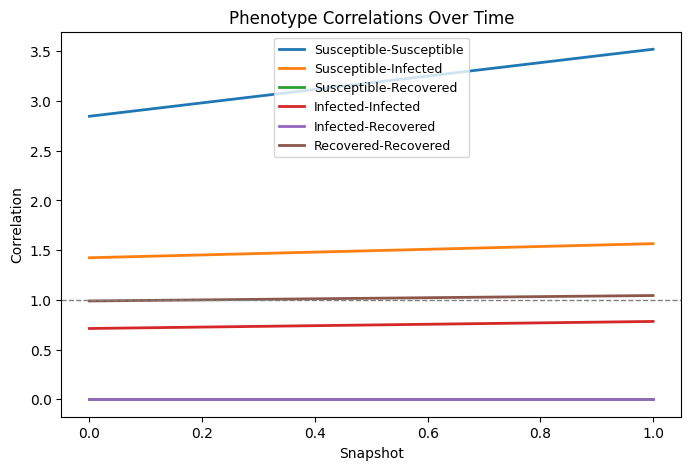

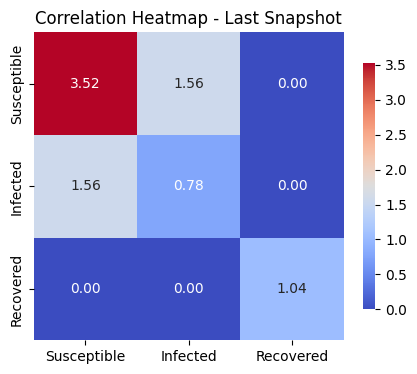

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KDTree
import os
from correlation_package import *

# -----------------------------
# Toy ABM snapshot series
# -----------------------------
# 5x5 grid, 3 phenotypes + 0 for empty
A1 = np.array([
    [1,1,0,2,0],
    [0,2,2,0,0],
    [3,0,1,1,0],
    [0,0,2,3,3],
    [1,0,0,0,2]
])

A2 = np.array([
    [1,0,0,2,2],
    [0,2,2,0,0],
    [3,0,1,1,0],
    [0,0,2,3,3],
    [1,0,0,0,2]
])

A_series = [A1, A2]
N = 3      # number of phenotypes
radius = 1.5

phenotype_labels = {1:"Susceptible", 2:"Infected", 3:"Recovered"}

corr_dict = correlation_time_series_unordered(A_series, N, radius)

# -----------------------------
# Plotting time series
# -----------------------------
time = np.arange(len(A_series))
plt.figure(figsize=(8,5))
for (i,j), vals in corr_dict.items():
    plt.plot(time, vals, lw=2, label=f"{phenotype_labels[i+1]}-{phenotype_labels[j+1]}")
plt.axhline(1.0, color='gray', linestyle='--', lw=1)
plt.xlabel("Snapshot")
plt.ylabel("Correlation")
plt.title("Phenotype Correlations Over Time")
plt.legend(fontsize=9)
plt.show()

# -----------------------------
# Plot heatmap for last snapshot
# -----------------------------
corr_matrix_last = correlation_matrix_for_snapshot_unordered(A_series[-1], N, radius)
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix_last, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=[phenotype_labels[p+1] for p in range(N)],
            yticklabels=[phenotype_labels[p+1] for p in range(N)],
            cbar_kws={"shrink":0.8})
plt.title("Correlation Heatmap - Last Snapshot")
plt.show()
